In [1]:
import calendar
import string
from pathlib import Path
from typing import cast

import cmocean.cm as cmo
import gsw
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import xarray as xr
from matplotlib import colormaps as cmaps  # pyright: ignore[reportAttributeAccessIssue]
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import distributions

## Dataset Loading

In [2]:
# For plotting months with colormap
colors = cmaps["viridis"](np.linspace(0, 1, 6))

FIG_SAVE_FMT = "png"

In [3]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"

In [4]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)

In [5]:
def get_overlapping_bottles(
    profiler: xr.Dataset,
    ship: xr.Dataset,
) -> tuple[xr.Dataset, xr.Dataset]:
    # find closest profiler data to OOI bottle samples
    profiler = profiler.sel(time=ship.time, method="nearest")
    ship_overlapping_bottles_slices: list[xr.Dataset] = []
    ship_notoverlapping_bottles_slices: list[xr.Dataset] = []
    prof_overlapping_bottles_slices: list[xr.Dataset] = []
    prof_notoverlapping_bottles_slices: list[xr.Dataset] = []
    for i, (t1, t2) in enumerate(zip(profiler.time.values, ship.time.values, strict=False)):
        # only consider profiler data within 1 day of OOI bottle samples
        if np.abs((t1 - t2) / np.timedelta64(1, "D")) < 1:
            ship_overlapping_bottles_slices.append(ship.isel(time=i))
            prof_overlapping_bottles_slices.append(profiler.isel(time=i))
        else:
            ship_notoverlapping_bottles_slices.append(ship.isel(time=i))
            prof_notoverlapping_bottles_slices.append(profiler.isel(time=i))
    print(
        f"{len(ship_overlapping_bottles_slices)} out of {len(ship_overlapping_bottles_slices) + len(ship_notoverlapping_bottles_slices)} bottle samples overlap with profiler deployments within one day.",
    )
    print(
        f"{len(ship_notoverlapping_bottles_slices)} out of {len(ship_overlapping_bottles_slices) + len(ship_notoverlapping_bottles_slices)} bottle samples do not overlap with profiler deployments within one day.",
    )

    # create combined datasets for overlapping and non-overlapping samples
    ship_overlapping_bottles = xr.concat(ship_overlapping_bottles_slices, dim="time")
    prof_overlapping_bottles = xr.concat(prof_overlapping_bottles_slices, dim="time")
    return ship_overlapping_bottles, prof_overlapping_bottles

## Inner Shelf Nitrate Bottle Sample Comparison

In [6]:
# Load the OOI Endurance Array ship data
fileList = Path(DATA_DIR / "ship/ea_ship_data/").glob("*.csv")
df_list = []
col_names = [
    "Station",
    "Start Time [UTC]",
    "Start Latitude [degrees]",
    "Start Longitude [degrees]",
    "CTD Pressure [db]",
    "CTD Salinity 1 [psu]",
    "CTD Salinity 2 [psu]",
    "CTD Temperature 1 [deg C]",
    "CTD Temperature 2 [deg C]",
    "Discrete Nitrate [uM]",
]
for f in fileList:
    df_temp = pd.read_csv(DATA_DIR / "ship/ea_ship_data/" / f, usecols=col_names)
    rows = df_temp.loc[df_temp["Station"] == "CE01"]
    df_list.append(rows)

inner_ooi_crse = pd.concat(df_list)
inner_ooi_crse = inner_ooi_crse.rename(
    columns={
        "Start Time [UTC]": "time",
        "Start Latitude [degrees]": "lat",
        "Start Longitude [degrees]": "lon",
        "CTD Pressure [db]": "pressure",
        "CTD Salinity 1 [psu]": "sal1",
        "CTD Salinity 2 [psu]": "sal2",
        "CTD Temperature 1 [deg C]": "temp1",
        "CTD Temperature 2 [deg C]": "temp2",
        "Discrete Nitrate [uM]": "nitrate",
    },
)
inner_ooi_crse["time"] = pd.to_datetime(inner_ooi_crse["time"])

# convert to xarray - need unique indices for time and pressure
inner_ooi_crse = inner_ooi_crse.iloc[
    np.unique(inner_ooi_crse.set_index(["time", "pressure"]).index, return_index=True)[1]
]
inner_ooi_crse = inner_ooi_crse.set_index(["time", "pressure"])
inner_ooi_crse = inner_ooi_crse.to_xarray()
inner_ooi_crse["time"] = pd.DatetimeIndex(inner_ooi_crse["time"].values)

# remove some bad data
inner_ooi_crse = inner_ooi_crse.where(inner_ooi_crse["nitrate"] > -100, drop=True)

# calculate potential density anomaly
inner_ooi_crse["pot_density_anom"] = gsw.density.sigma0(
    inner_ooi_crse["sal1"],
    gsw.conversions.CT_from_t(
        inner_ooi_crse["sal1"],
        inner_ooi_crse["temp1"],
        inner_ooi_crse["pressure"],
    ),
)

In [7]:
ooi_overlapping_bottles, prof_overlapping_bottles = get_overlapping_bottles(
    profiler=inner_nitrate,
    ship=inner_ooi_crse,
)

6 out of 28 bottle samples overlap with profiler deployments within one day.
22 out of 28 bottle samples do not overlap with profiler deployments within one day.


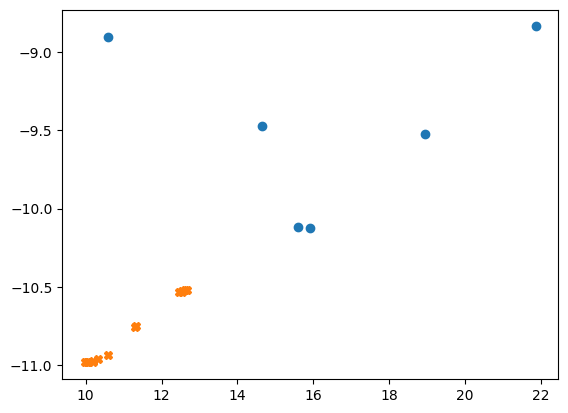

In [8]:
plt.plot(
    ooi_overlapping_bottles.isel(time=2).nitrate,
    -ooi_overlapping_bottles.isel(time=2).temp1,
    "o",
)
plt.plot(
    prof_overlapping_bottles.isel(time=2).nitrate,
    -prof_overlapping_bottles.isel(time=2).temperature,
    "X",
)

In [9]:
# ctd data from NH, nhl_crse_ctd = nh line cruise ctd data
inner_nhl_crse_ctd = xr.open_dataset(
    DATA_DIR / "NHL_Gridded/newport_hydrographic_line_gridded_sections.nc",
)
# fix some xr stuff, assign coords, remove unnecessary dims, etc
inner_nhl_crse_ctd = inner_nhl_crse_ctd.assign_coords(
    date=inner_nhl_crse_ctd["time"].astype("datetime64[D]"),
)
inner_nhl_crse_ctd = inner_nhl_crse_ctd.swap_dims({"time": "date"})
inner_nhl_crse_ctd["longitude"] = inner_nhl_crse_ctd["longitude"] - 360
inner_nhl_crse_ctd = inner_nhl_crse_ctd.squeeze()

# nitrate data from NH line cruises, nhl_crse_nit = nh line cruise nitrate data
inner_nhl_crse_nit = pd.read_csv(DATA_DIR / "ship/Nutrients_4_Andrew_all_NCC.csv")

# bin the bottle sample data by date and pressure
nh_pressure_grid = inner_nhl_crse_ctd["pressure"]
nh_time_grid = inner_nhl_crse_ctd["date"]
inner_nhl_crse_nit["Sample Date"] = pd.to_datetime(
    inner_nhl_crse_nit["Sample Date"].values,
    unit="ns",
)

nitr_tbin, pres_tbin, time_tbin, long_tbin, stat_tbin = [], [], [], [], []
for i, t in enumerate(inner_nhl_crse_ctd["date"].values):
    # find places where nitrate data lines up with ctd data
    # need exact date matches - don't want nearest neighbor for this step
    time_mask = np.where(inner_nhl_crse_nit["Sample Date"] == t)
    for n, d, s, p, lon in zip(
        inner_nhl_crse_nit["no3"].values[time_mask],
        inner_nhl_crse_nit["Sample Date"].values[time_mask],
        inner_nhl_crse_nit["Station"].values[time_mask],
        inner_nhl_crse_nit["pressure"].values[time_mask],
        inner_nhl_crse_nit["Longitude"].values[time_mask],
        strict=False,
    ):
        nitr_tbin.append(n)
        pres_tbin.append(p)
        time_tbin.append(d)
        long_tbin.append(lon)
        stat_tbin.append(s)

# make numpy arrays
nitr_tbin, pres_tbin, time_tbin, long_tbin, stat_tbin = (
    np.array(nitr_tbin),
    np.array(pres_tbin),
    np.array(time_tbin),
    np.array(long_tbin),
    np.array(stat_tbin),
)

# make dataarrays for vectorized indexing, doesn't work with np arrays for some reason
pres_targ = xr.DataArray(pres_tbin, dims="date")
time_targ = xr.DataArray(time_tbin, dims="date")
long_targ = xr.DataArray(long_tbin, dims="date")

# bin the ctd data using the arrays from the bottle sample binning, using nearest binning method, e.g., if pressure=0 from bottle, then pressure=1 from ship since this is closest.
inner_nhl_crse = inner_nhl_crse_ctd.sel(
    date=time_targ,
    pressure=pres_targ,
    longitude=long_targ,
    method="nearest",
)

# add nitrate and station
inner_nhl_crse["nitrate"] = (("date"), nitr_tbin)
inner_nhl_crse["station"] = (("date"), stat_tbin)

# view created xarray
inner_nhl_crse = inner_nhl_crse.where(
    (inner_nhl_crse.station == "NH01") | (inner_nhl_crse.station == "NH03"),
    drop=True,
)
inner_nhl_crse = inner_nhl_crse.swap_dims({"date": "time"})

In [10]:
nhl_overlapping_bottles, prof_overlapping_bottles = get_overlapping_bottles(
    profiler=inner_nitrate,
    ship=inner_nhl_crse,
)

56 out of 451 bottle samples overlap with profiler deployments within one day.
395 out of 451 bottle samples do not overlap with profiler deployments within one day.


C:\Users\asche\AppData\Local\Temp\ipykernel_20576\387528787.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


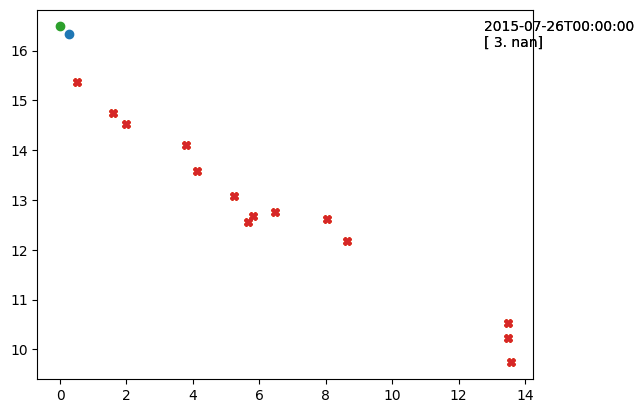

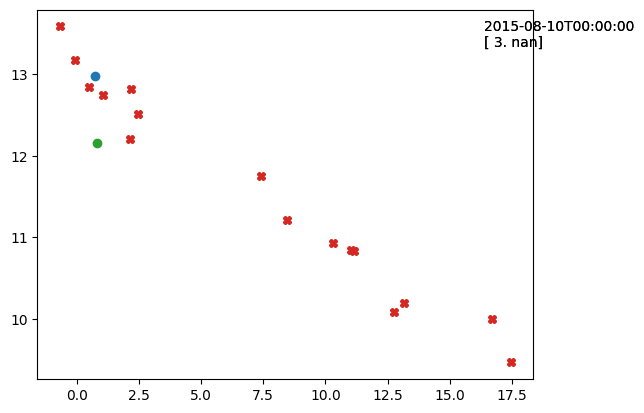

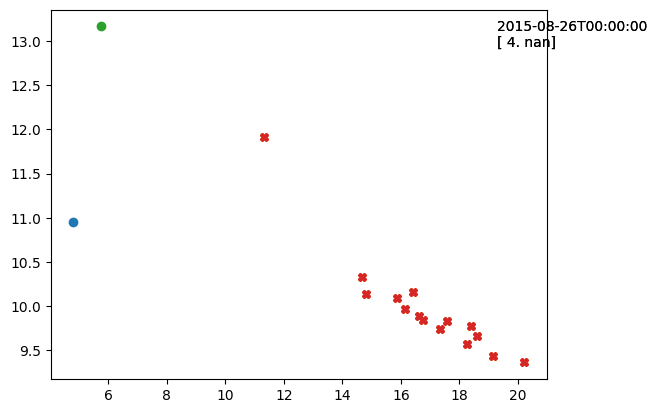

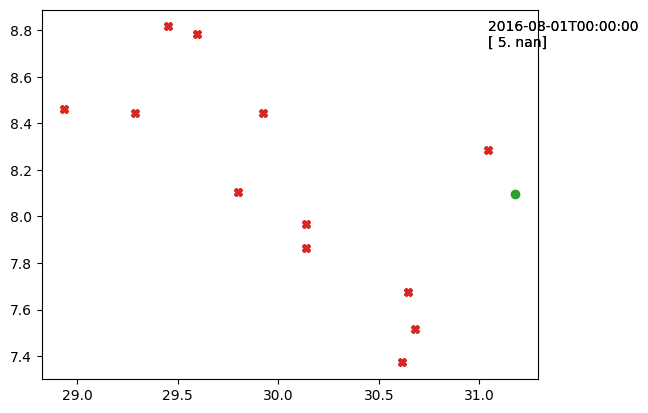

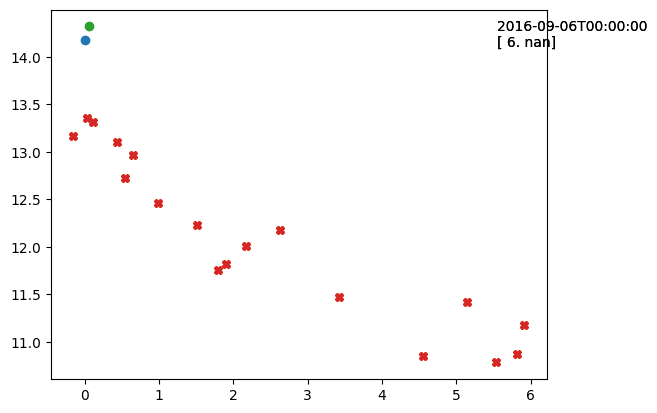

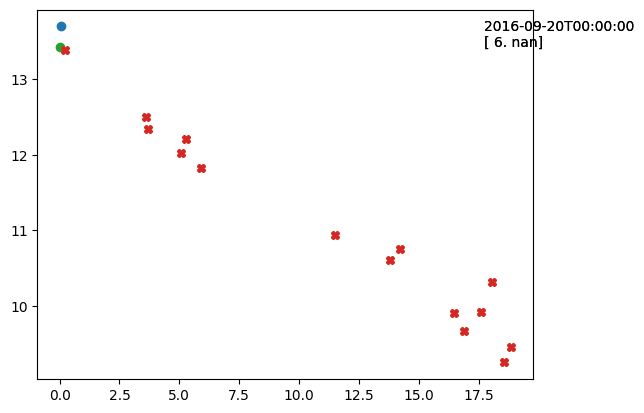

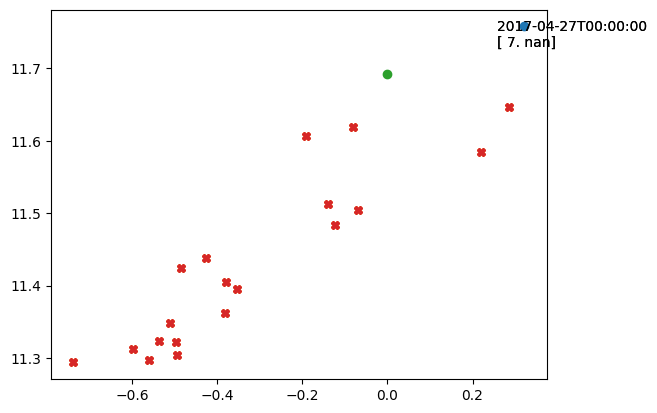

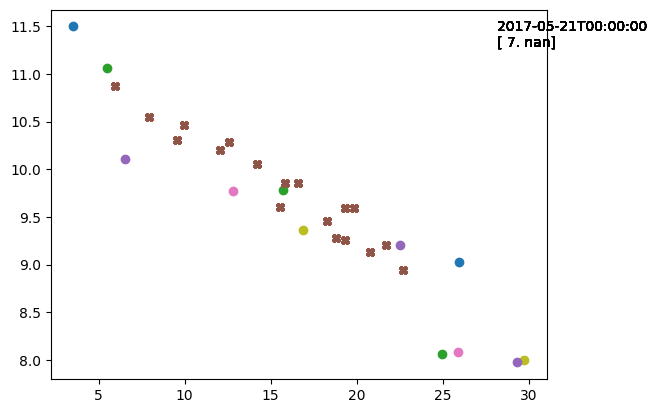

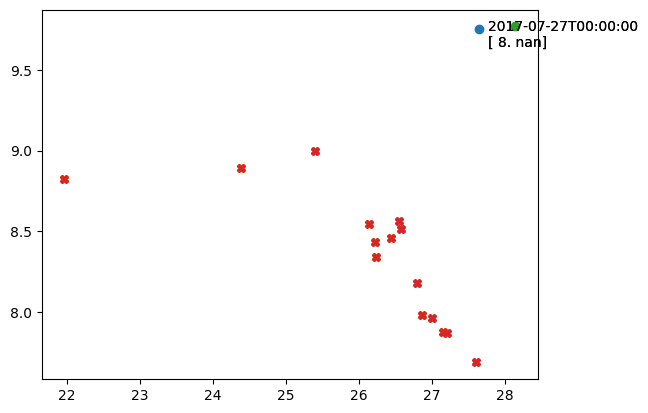

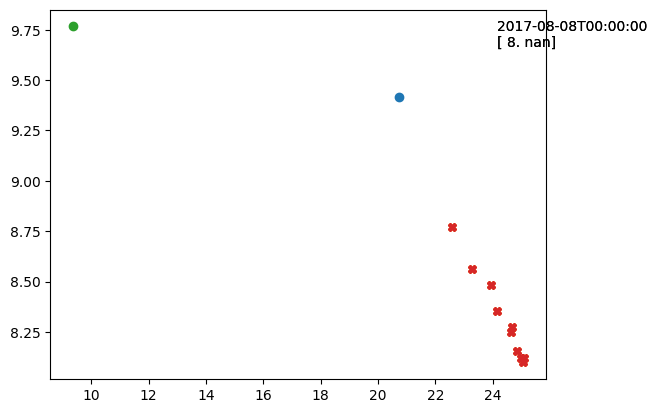

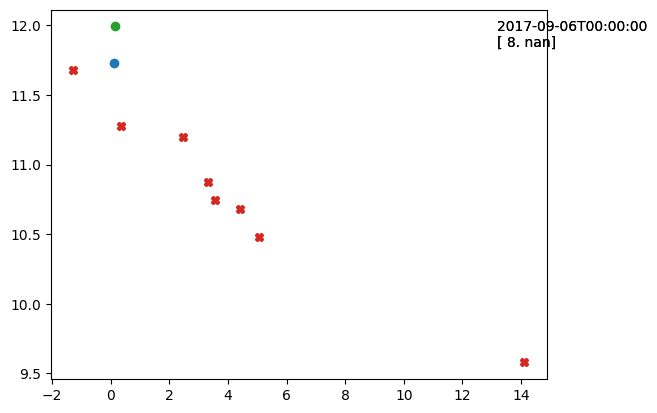

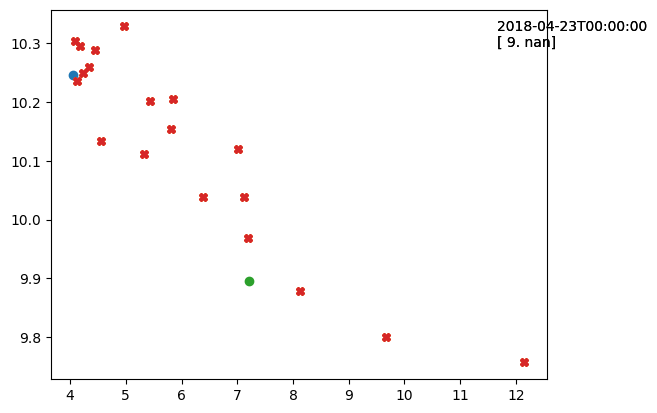

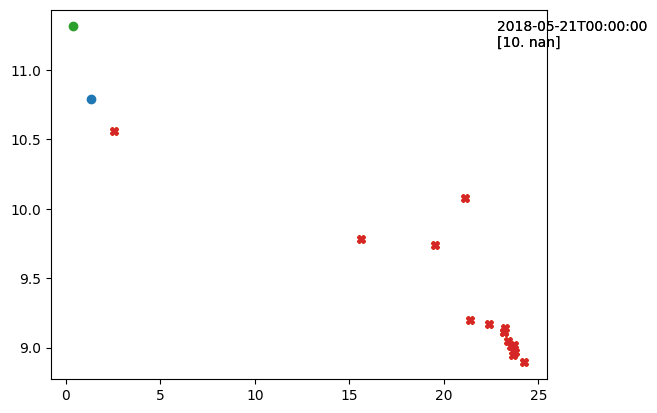

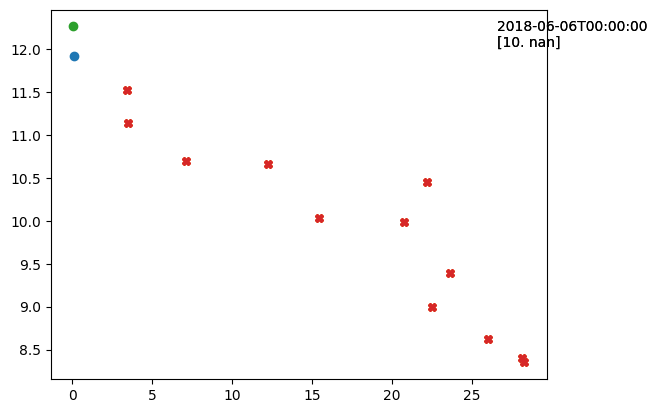

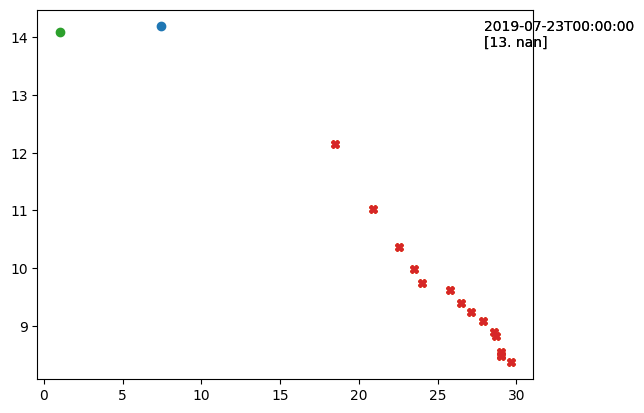

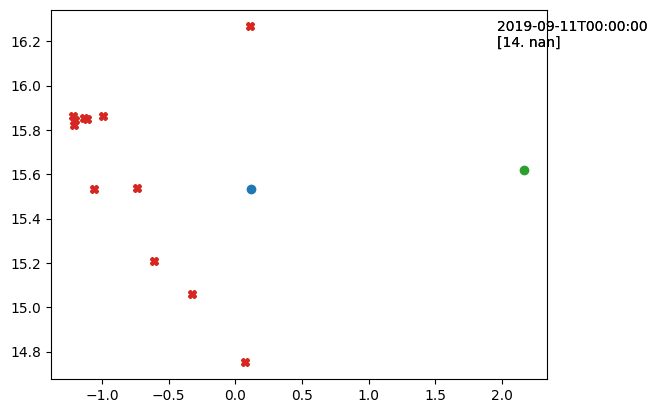

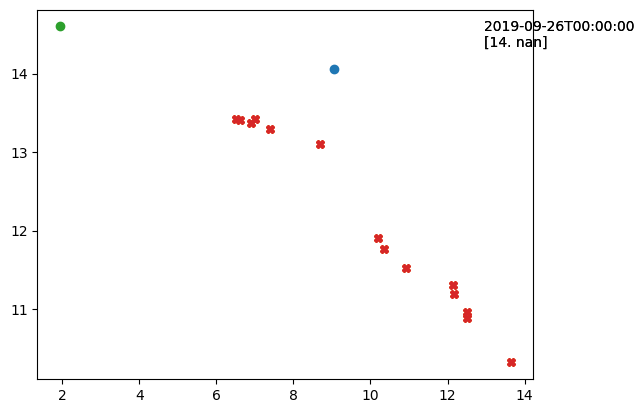

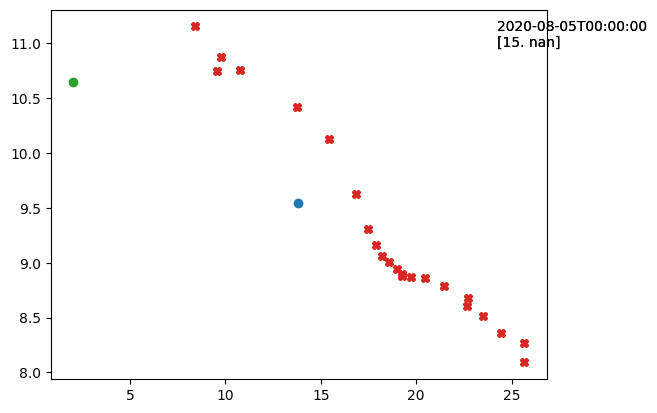

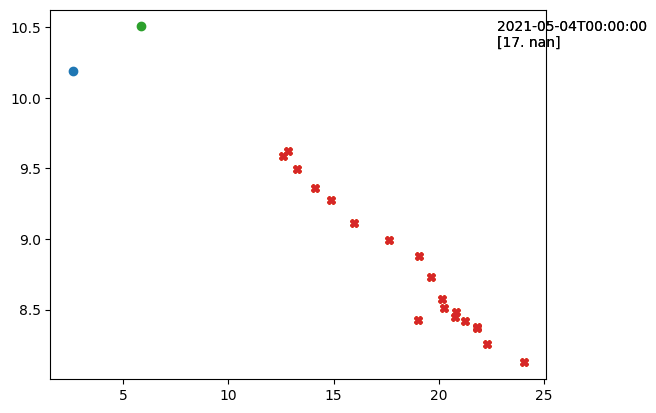

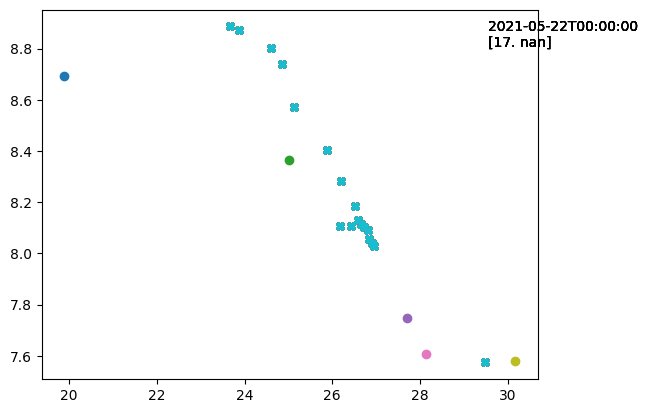

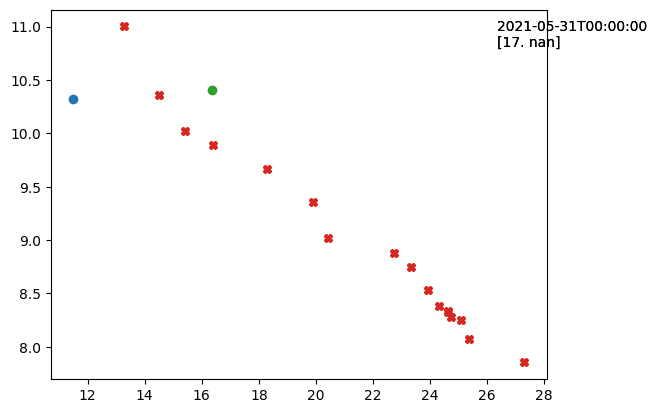

In [11]:
temp = nhl_overlapping_bottles.isel(time=0).date
for i in range(len(nhl_overlapping_bottles.time)):
    if temp != nhl_overlapping_bottles.isel(time=i).date:
        plt.figure()
    plt.plot(
        nhl_overlapping_bottles.isel(time=i).nitrate,
        nhl_overlapping_bottles.isel(time=i).temperature,
        "o",
    )
    plt.plot(
        prof_overlapping_bottles.isel(time=i).nitrate,
        prof_overlapping_bottles.isel(time=i).temperature,
        "X",
    )
    plt.annotate(
        f"{nhl_overlapping_bottles.isel(time=i).date.values}\n{np.unique(prof_overlapping_bottles.isel(time=i).deployment.values)}",
        (0.9, 0.9),
        xycoords="axes fraction",
    )
    temp = nhl_overlapping_bottles.isel(time=i).date

## Mid Shelf Nitrate Bottle Sample Comparison

In [12]:
# loading ooi cruise data df = ooi cruise data
fileList = Path(DATA_DIR / "ship/ea_ship_data/").glob("*.csv")
df_list = []
col_names = [
    "Station",
    "Start Time [UTC]",
    "Start Latitude [degrees]",
    "Start Longitude [degrees]",
    "CTD Pressure [db]",
    "CTD Salinity 1 [psu]",
    "CTD Salinity 2 [psu]",
    "CTD Temperature 1 [deg C]",
    "CTD Temperature 2 [deg C]",
    "Discrete Nitrate [uM]",
]
for f in fileList:
    df_temp = pd.read_csv(DATA_DIR / "ship/ea_ship_data/" / f, usecols=col_names)
    rows = df_temp.loc[df_temp["Station"] == "CE02"]
    df_list.append(rows)

mid_shelf_ooi_crse = pd.concat(df_list)
mid_shelf_ooi_crse = mid_shelf_ooi_crse.rename(
    columns={
        "Start Time [UTC]": "time",
        "Start Latitude [degrees]": "lat",
        "Start Longitude [degrees]": "lon",
        "CTD Pressure [db]": "pressure",
        "CTD Salinity 1 [psu]": "sal1",
        "CTD Salinity 2 [psu]": "sal2",
        "CTD Temperature 1 [deg C]": "temp1",
        "CTD Temperature 2 [deg C]": "temp2",
        "Discrete Nitrate [uM]": "nitrate",
    },
)
mid_shelf_ooi_crse["time"] = pd.to_datetime(mid_shelf_ooi_crse["time"])
# ooi_cruse = mid_shelf_ooi_crse.set_index(["time", "pressure"])
mid_shelf_ooi_crse = mid_shelf_ooi_crse.iloc[
    np.unique(
        mid_shelf_ooi_crse.set_index(["time", "pressure"]).index,
        return_index=True,
    )[1]
]
mid_shelf_ooi_crse = mid_shelf_ooi_crse.set_index(["time", "pressure"])
mid_shelf_ooi_crse = mid_shelf_ooi_crse.to_xarray()
mid_shelf_ooi_crse["time"] = pd.DatetimeIndex(mid_shelf_ooi_crse["time"].values)
mid_shelf_ooi_crse = mid_shelf_ooi_crse.where(
    mid_shelf_ooi_crse.nitrate > -100,
    drop=True,
)
mid_shelf_ooi_crse["pot_density_anom"] = gsw.density.sigma0(
    mid_shelf_ooi_crse["sal1"],
    gsw.conversions.CT_from_t(
        mid_shelf_ooi_crse["sal1"],
        mid_shelf_ooi_crse["temp1"],
        mid_shelf_ooi_crse["pressure"],
    ),
)

In [13]:
ooi_overlapping_bottles, prof_overlapping_bottles = get_overlapping_bottles(
    profiler=midshelf_nitrate,
    ship=mid_shelf_ooi_crse,
)

10 out of 26 bottle samples overlap with profiler deployments within one day.
16 out of 26 bottle samples do not overlap with profiler deployments within one day.


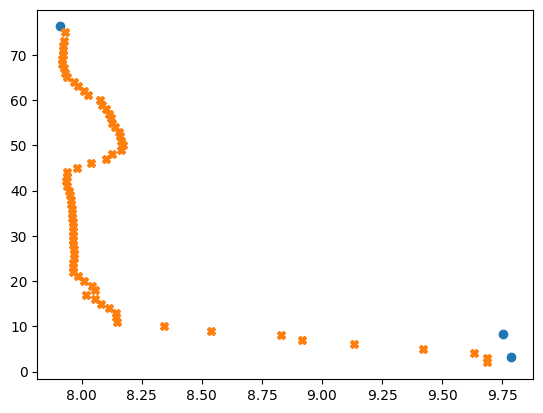

In [14]:
plt.plot(
    ooi_overlapping_bottles.isel(time=-1).temp1,
    ooi_overlapping_bottles.isel(time=-1).pressure,
    "o",
)
plt.plot(
    prof_overlapping_bottles.isel(time=-1).temperature,
    prof_overlapping_bottles.isel(time=-1).depth,
    "X",
)

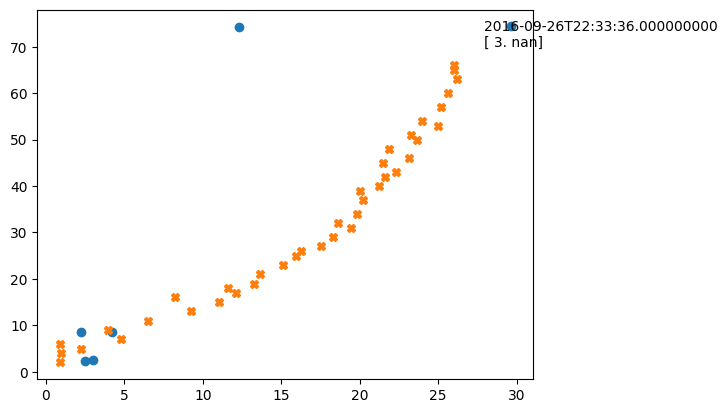

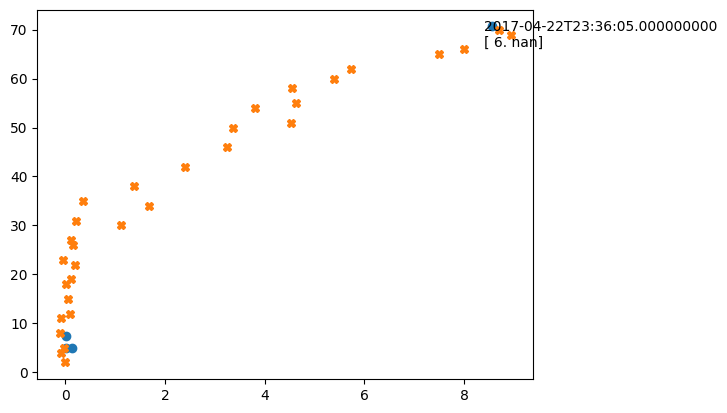

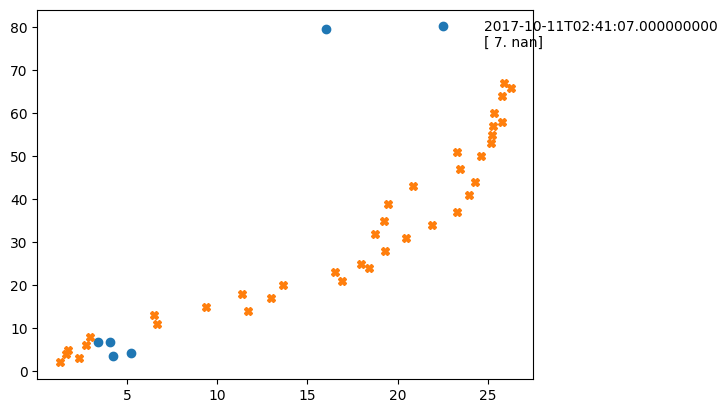

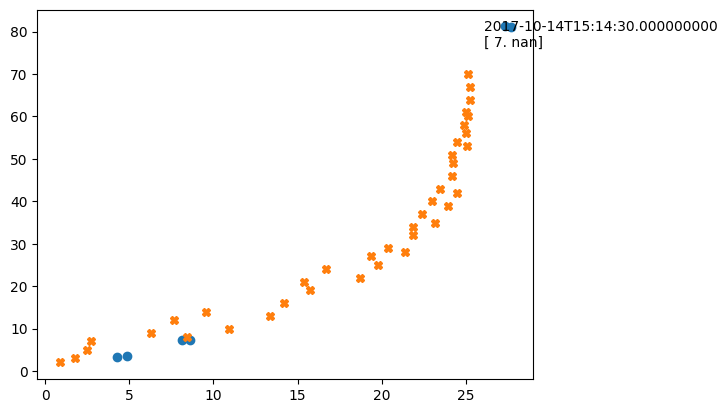

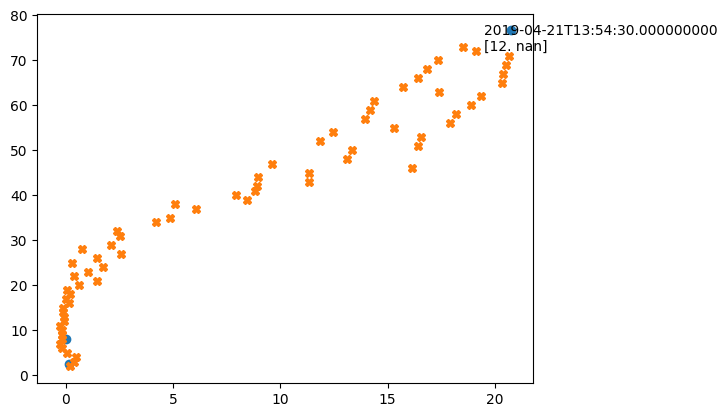

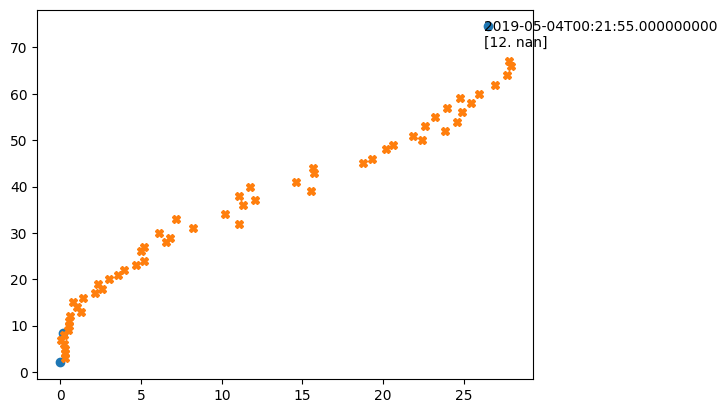

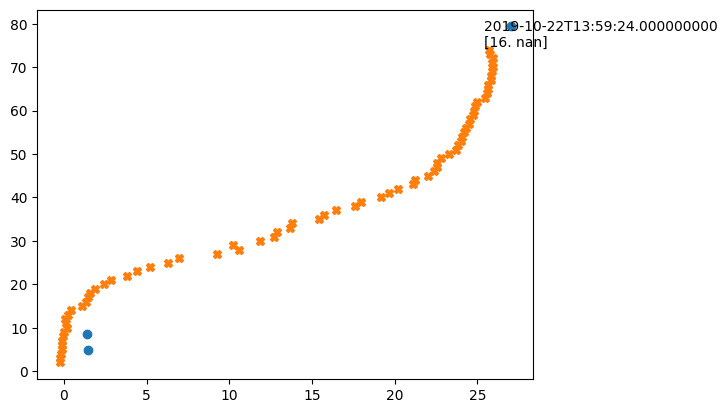

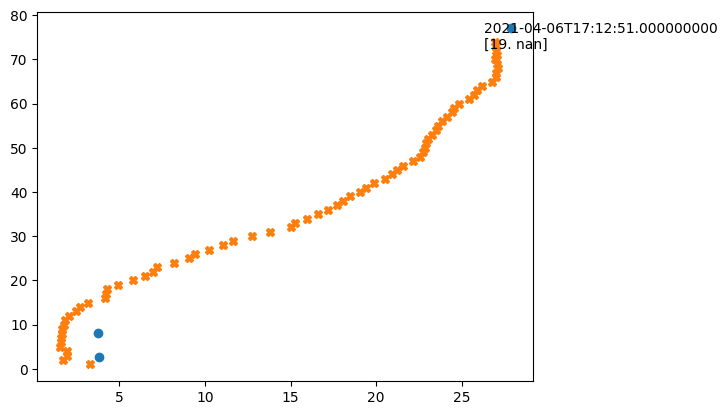

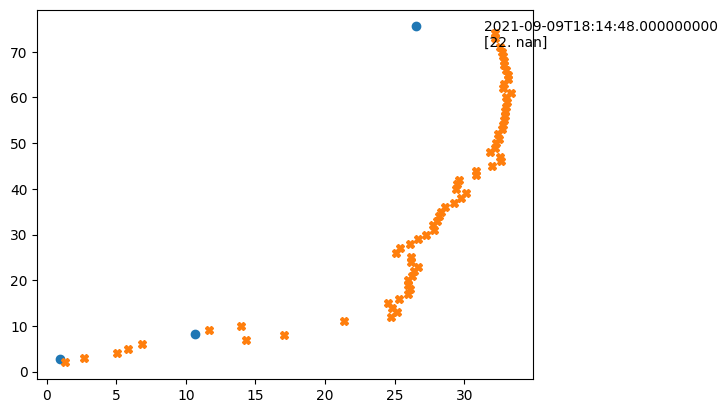

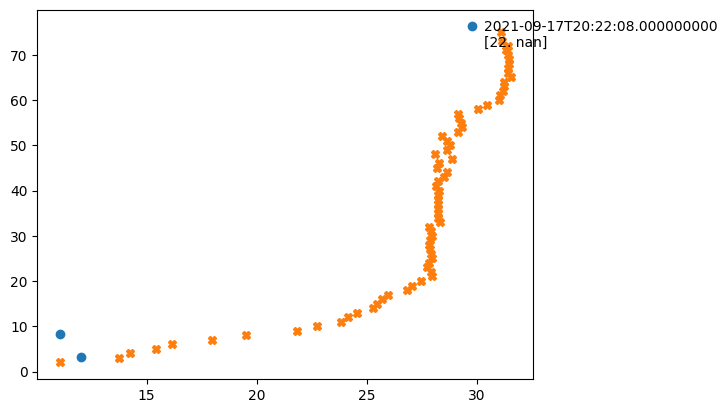

In [15]:
temp = ooi_overlapping_bottles.isel(time=0).time
for i in range(len(ooi_overlapping_bottles.time)):
    plt.figure()
    plt.plot(
        ooi_overlapping_bottles.isel(time=i).nitrate,
        ooi_overlapping_bottles.isel(time=i).pressure,
        "o",
    )
    plt.plot(
        prof_overlapping_bottles.isel(time=i).nitrate,
        prof_overlapping_bottles.isel(time=i).depth,
        "X",
    )
    plt.annotate(
        f"{ooi_overlapping_bottles.isel(time=i).time.values}\n{np.unique(prof_overlapping_bottles.isel(time=i).deployment.values)}",
        (0.9, 0.9),
        xycoords="axes fraction",
    )
    temp = ooi_overlapping_bottles.isel(time=i).time

In [16]:
# ctd data from NH, nhl_crse_ctd = nh line cruise ctd data
mid_nhl_crse_ctd = xr.open_dataset(
    DATA_DIR / "NHL_Gridded/newport_hydrographic_line_gridded_sections.nc",
)
# fix some xr stuff, assign coords, remove unnecessary dims, etc
mid_nhl_crse_ctd = mid_nhl_crse_ctd.assign_coords(
    date=mid_nhl_crse_ctd["time"].astype("datetime64[D]"),
)
mid_nhl_crse_ctd = mid_nhl_crse_ctd.swap_dims({"time": "date"})
mid_nhl_crse_ctd["longitude"] = mid_nhl_crse_ctd["longitude"] - 360
mid_nhl_crse_ctd = mid_nhl_crse_ctd.squeeze()

# nitrate data from NH line cruises, nhl_crse_nit = nh line cruise nitrate data
mid_nhl_crse_nit = pd.read_csv(DATA_DIR / "ship/Nutrients_4_Andrew_all_NCC.csv")

# bin the bottle sample data by date and pressure
nh_pressure_grid = mid_nhl_crse_ctd["pressure"]
nh_time_grid = mid_nhl_crse_ctd["date"]
mid_nhl_crse_nit["Sample Date"] = pd.to_datetime(
    mid_nhl_crse_nit["Sample Date"].values,
    unit="ns",
)

nitr_tbin, pres_tbin, time_tbin, long_tbin, stat_tbin = [], [], [], [], []
for i, t in enumerate(mid_nhl_crse_ctd["date"].values):
    # find places where nitrate data lines up with ctd data
    # need exact date matches - don't want nearest neighbor for this step
    time_mask = np.where(mid_nhl_crse_nit["Sample Date"] == t)
    for n, d, s, p, lon in zip(
        mid_nhl_crse_nit["no3"].values[time_mask],
        mid_nhl_crse_nit["Sample Date"].values[time_mask],
        mid_nhl_crse_nit["Station"].values[time_mask],
        mid_nhl_crse_nit["pressure"].values[time_mask],
        mid_nhl_crse_nit["Longitude"].values[time_mask],
        strict=False,
    ):
        nitr_tbin.append(n)
        pres_tbin.append(p)
        time_tbin.append(d)
        long_tbin.append(lon)
        stat_tbin.append(s)

# make numpy arrays
nitr_tbin, pres_tbin, time_tbin, long_tbin, stat_tbin = (
    np.array(nitr_tbin),
    np.array(pres_tbin),
    np.array(time_tbin),
    np.array(long_tbin),
    np.array(stat_tbin),
)

# make dataarrays for vectorized indexing, doesn't work with np arrays for some reason
pres_targ = xr.DataArray(pres_tbin, dims="date")
time_targ = xr.DataArray(time_tbin, dims="date")
long_targ = xr.DataArray(long_tbin, dims="date")

# bin the ctd data using the arrays from the bottle sample binning, using nearest binning method, e.g., if pressure=0 from bottle, then pressure=1 from ship since this is closest.
mid_nhl_crse = mid_nhl_crse_ctd.sel(
    date=time_targ,
    pressure=pres_targ,
    longitude=long_targ,
    method="nearest",
)

# add nitrate and station
mid_nhl_crse["nitrate"] = (("date"), nitr_tbin)
mid_nhl_crse["station"] = (("date"), stat_tbin)

# view created xarray
mid_nhl_crse = mid_nhl_crse.where(mid_nhl_crse.station == "NH10", drop=True)
mid_nhl_crse = mid_nhl_crse.swap_dims({"date": "time"})

In [17]:
nhl_overlapping_bottles, prof_overlapping_bottles = get_overlapping_bottles(
    profiler=midshelf_nitrate,
    ship=mid_nhl_crse,
)

35 out of 277 bottle samples overlap with profiler deployments within one day.
242 out of 277 bottle samples do not overlap with profiler deployments within one day.


## Nitrate Density Relationship and Comparison with Bottle Samples

Mean N below 25.8 sigma: 6.552617833228939
Mean N above 25.8 sigma: 25.843337232353228
Mean N below 25.8 sigma: 9.266042720262504
Mean N above 25.8 sigma: 27.34084088292088


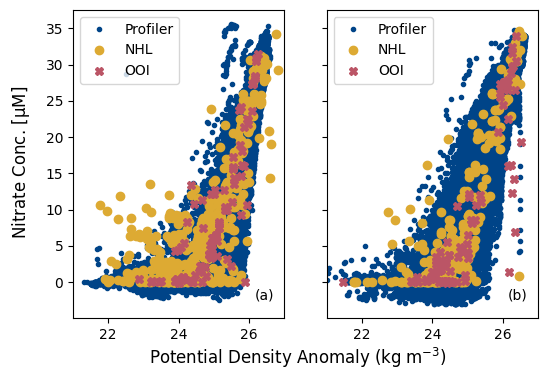

In [18]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
# ax0.plot(midshelf_nitrate.density, midshelf_nitrate.nitrate ,'.', color='#004488', label='Profiler', rasterized=True)
# ax0.plot(nhl_crse.potential_density, nhl_crse.nitrate, 'o', color='#DDAA33', label='NHL')
ax0.plot(
    inner_nitrate["density"],
    inner_nitrate["nitrate"],
    ".",
    color="#004488",
    label="Profiler",
)
ax0.plot(
    inner_nhl_crse["potential_density"],
    inner_nhl_crse["nitrate"],
    "o",
    color="#DDAA33",
    label="NHL",
)
ax0.plot(
    inner_ooi_crse["pot_density_anom"],
    inner_ooi_crse["nitrate"],
    "X",
    color="#BB5566",
    label="OOI",
)
ax0.set_xlim(21, 27)

handles, labels = ax0.get_legend_handles_labels()
by_label = dict(
    zip(labels, handles, strict=False),
)  # dicts can't have duplicate keys, avoids duplicate legend entries
ax0.legend(by_label.values(), by_label.keys())
print(
    f"Mean N below 25.8 sigma: {np.nanmean(inner_nitrate.where(inner_nitrate['density'] < 25.8)['nitrate'])}",
)
print(
    f"Mean N above 25.8 sigma: {np.nanmean(inner_nitrate.where(inner_nitrate['density'] > 25.8)['nitrate'])}",
)

ax1.plot(
    midshelf_nitrate["density"],
    midshelf_nitrate["nitrate"],
    ".",
    color="#004488",
    label="Profiler",
    rasterized=True,
)
ax1.plot(
    mid_nhl_crse["potential_density"],
    mid_nhl_crse["nitrate"],
    "o",
    color="#DDAA33",
    label="NHL",
)
ax1.plot(
    mid_shelf_ooi_crse["pot_density_anom"],
    mid_shelf_ooi_crse["nitrate"],
    "X",
    color="#BB5566",
    label="OOI",
)
ax1.set_xlim(21, 27)
# ax1.set_xlabel('Density Anomaly ($\mathsf{kg \; m^{-3}}$)')
# ax1.set_ylabel('Nitrate Conc. [$\mathsf{\mu M}$]')
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(
    zip(labels, handles, strict=False),
)  # dicts can't have duplicate keys, avoids duplicate legend entries
ax1.legend(by_label.values(), by_label.keys())
fig.supxlabel("Potential Density Anomaly ($\\mathsf{kg \\; m^{-3}}$)", y=-0.02)
fig.supylabel("Nitrate Conc. [$\\mathsf{\\mu M}$]", x=0.02)

ax0.text(
    0.95,
    0.05,
    "(a)",
    transform=ax0.transAxes,
    fontsize=10,
    ha="right",
    va="bottom",
)
ax1.text(
    0.95,
    0.05,
    "(b)",
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="bottom",
)

print(
    f"Mean N below 25.8 sigma: {np.nanmean(midshelf_nitrate.where(midshelf_nitrate['density'] < 25.8)['nitrate'])}",
)
print(
    f"Mean N above 25.8 sigma: {np.nanmean(midshelf_nitrate.where(midshelf_nitrate['density'] > 25.8)['nitrate'])}",
)

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/nitrate-density.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    bbox_inches="tight",
    dpi=600,
)

## Density by Deployment Times

In [19]:
GLOBEC_TIME = slice(np.datetime64("1997-01-01"), np.datetime64("2004-12-31"))
NANOOS_TIME = slice(np.datetime64("2006-07-01"), np.datetime64("2014-09-30"))
OOI_TIME = slice(np.datetime64("2015-04-01"), None)

In [20]:
nhl_ctd = xr.open_dataset(
    DATA_DIR / "NHL_Gridded/newport_hydrographic_line_gridded_sections.nc",
)
nhl_ctd["longitude"] = nhl_ctd["longitude"] - 360
nhl_ctd = nhl_ctd.sel(longitude=-124.3).squeeze().dropna("pressure", how="all")

In [21]:
nhl_ctd_globec = nhl_ctd.sel(time=GLOBEC_TIME)
nhl_ctd_nanoos = nhl_ctd.sel(time=NANOOS_TIME)
nhl_ctd_ooi = nhl_ctd.sel(time=OOI_TIME)

Text(0, 0.5, 'Potential Density Anomaly ($\\mathsf{kg \\; m^{-3}}$)')

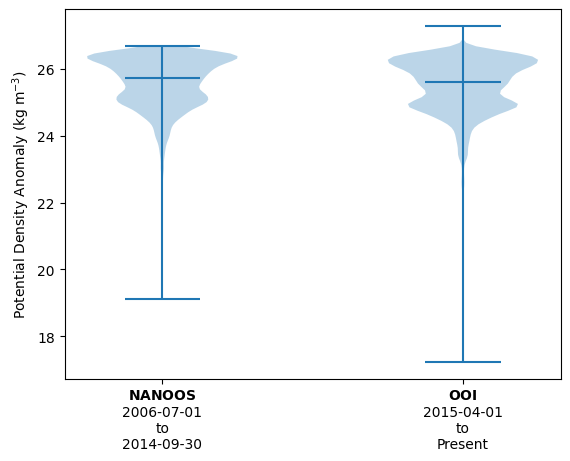

In [22]:
plt.violinplot(
    [
        # nhl_ctd_globec["potential_density"].dropna("time").to_numpy().flatten(),
        nhl_ctd_nanoos["potential_density"].dropna("time").to_numpy().flatten(),
        nhl_ctd_ooi["potential_density"].dropna("time").to_numpy().flatten(),
    ],
    positions=[1, 2],
    # showmeans=True,
    showmedians=True,
    # quantiles=[0.25, 0.5, 0.75],
)
# plt.ylim(22, 28)
x_tick_labels = [
    # f"$\\mathbf{{GLOBEC}}$\n{GLOBEC_TIME.start}\nto\n{GLOBEC_TIME.stop}",
    f"$\\mathbf{{NANOOS}}$\n{NANOOS_TIME.start}\nto\n{NANOOS_TIME.stop}",
    f"$\\mathbf{{OOI}}$\n{OOI_TIME.start}\nto\n{'Present' if OOI_TIME.stop is None else OOI_TIME.stop}",
]
plt.gca().set_xticks([1, 2], x_tick_labels)
plt.ylabel("Potential Density Anomaly ($\\mathsf{kg \\; m^{-3}}$)")

In [23]:
def compare_nhl_densities(ds1: xr.Dataset, ds2: xr.Dataset):
    pressure = np.intersect1d(ds1["pressure"], ds2["pressure"])
    for p in pressure:
        ds1_p = ds1.sel(pressure=p, method="nearest").dropna("time")
        ds2_p = ds2.sel(pressure=p, method="nearest").dropna("time")
        if len(ds1_p.time) > 5 and len(ds2_p.time) > 5:
            ds1_p_stats = sm.stats.DescrStatsW(
                ds1_p["potential_density"].to_numpy().flatten(),
            )
            ds2_p_stats = sm.stats.DescrStatsW(
                ds2_p["potential_density"].to_numpy().flatten(),
            )
            ds1_ds2 = sm.stats.CompareMeans(ds1_p_stats, ds2_p_stats)
            if ds1_ds2.ttest_ind(alternative="two-sided")[1] < 0.05:
                print(f"Pressure: {p} dbar")
                print(ds1_ds2.ttest_ind(alternative="two-sided"))

In [24]:
nhl_ctd_nanoos_summer = nhl_ctd_nanoos.sel(
    time=nhl_ctd_nanoos["time.month"].isin([5, 6, 7, 8, 9]),
)
nhl_ctd_ooi_summer = nhl_ctd_ooi.sel(
    time=nhl_ctd_ooi["time.month"].isin([5, 6, 7, 8, 9]),
)

In [25]:
compare_nhl_densities(nhl_ctd_nanoos, nhl_ctd_ooi)

Pressure: 68.0 dbar
(np.float64(2.018357910262693), np.float64(0.044553823401532085), np.float64(267.0))
Pressure: 69.0 dbar
(np.float64(2.134095074554761), np.float64(0.033746178790618836), np.float64(267.0))
Pressure: 70.0 dbar
(np.float64(2.1917008649806573), np.float64(0.029264939096074503), np.float64(267.0))
Pressure: 71.0 dbar
(np.float64(2.25651591576458), np.float64(0.02484728307513634), np.float64(267.0))
Pressure: 72.0 dbar
(np.float64(2.2738506757702566), np.float64(0.023772041644759864), np.float64(266.0))
Pressure: 73.0 dbar
(np.float64(2.319316386966581), np.float64(0.021135613272105825), np.float64(266.0))
Pressure: 74.0 dbar
(np.float64(2.3242542817595364), np.float64(0.020862473212631186), np.float64(267.0))
Pressure: 75.0 dbar
(np.float64(2.3187341077555645), np.float64(0.021164833103860716), np.float64(267.0))
Pressure: 76.0 dbar
(np.float64(2.3243973933729367), np.float64(0.020854685078918456), np.float64(267.0))
Pressure: 77.0 dbar
(np.float64(2.2843546358754816),

In [26]:
def generate_harmonics(t, harmonics: int, f: float = 1 / 365.2422):
    exog = np.full((harmonics * 2, len(t)), np.nan)
    for i in range(harmonics * 2):
        if i % 2 == 0:
            exog[i] = np.sin((i // 2 + 1) * 2 * np.pi * f * t)
        else:
            exog[i] = np.cos((i // 2 + 1) * 2 * np.pi * f * t)
    exog = exog.T
    exog = sm.add_constant(exog)
    return exog


def calc_climatology(t, y, harmonics: int, f: float = 1 / 365.2422):
    exog = generate_harmonics(t, harmonics=harmonics, f=f)
    endog = y
    mod = sm.OLS(endog, exog)
    res = mod.fit()
    return res.params @ exog.T, res


def calc_climatology_by_depth(da: xr.DataArray, harmonics: int):
    pressure = da["pressure"]
    fit_list = []
    for p in pressure:
        ds_p = da.sel(pressure=p).dropna("time")
        t_fit = np.arange(1, 366)
        exog = generate_harmonics(t_fit, harmonics=harmonics)
        if len(ds_p.time) > 50:
            ds_p = ds_p.groupby("time.dayofyear").mean()
            _, res = calc_climatology(
                ds_p["dayofyear"].to_numpy(),
                ds_p.to_numpy(),
                harmonics=harmonics,
            )
            fit_ds = xr.Dataset(
                {
                    "fit": (
                        ("dayofyear"),
                        res.params @ generate_harmonics(t_fit, harmonics=harmonics).T,
                    ),
                    "fit_std": (
                        ("dayofyear"),
                        np.sqrt(
                            res.mse_resid
                            * np.einsum(
                                "ij,jk,ki->i",
                                exog,
                                res.normalized_cov_params,
                                exog.T,
                            ),
                        ),
                    ),
                    "fit_ci": (
                        ("dayofyear"),
                        distributions.t.ppf(0.91, t_fit.size - exog.shape[1])
                        * np.sqrt(
                            res.mse_resid
                            * np.einsum(
                                "ij,jk,ki->i",
                                exog,
                                res.normalized_cov_params,
                                exog.T,
                            ),
                        ),
                    ),
                },
                coords={"dayofyear": t_fit},
            )
            fit_list.append(fit_ds)
        else:
            fit_ds = xr.Dataset(
                {
                    "fit": (("dayofyear"), np.full(365, np.nan)),
                    "fit_std": (("dayofyear"), np.full(365, np.nan)),
                    "fit_ci": (("dayofyear"), np.full(365, np.nan)),
                },
                coords={"dayofyear": t_fit},
            )
            fit_list.append(fit_ds)
    fit_ds = xr.concat(fit_list, dim="pressure")
    fit_ds = fit_ds.assign_coords({"pressure": pressure})

    return fit_ds

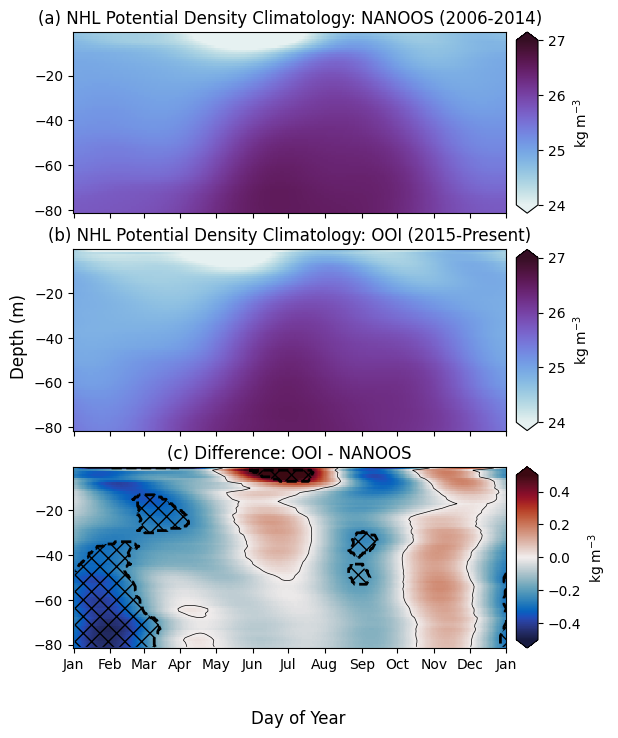

In [27]:
def add_colorbar(ax, mappable, label: str):
    divider = make_axes_locatable(ax)
    ax_cb = divider.new_horizontal(size="5%", pad=0.1, axes_class=plt.Axes)
    fig.add_axes(ax_cb)
    cbar = plt.colorbar(mappable, cax=ax_cb, extend="both")
    cbar.set_label(label, fontsize=10)


nhl_clima_nanoos = calc_climatology_by_depth(
    nhl_ctd_nanoos["potential_density"],
    harmonics=3,
)
nhl_clima_ooi = calc_climatology_by_depth(nhl_ctd_ooi["potential_density"], harmonics=3)

fig, (ax0, ax1, ax2) = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(6, 8),
    sharex=True,
    sharey=True,
)
pcm0 = ax0.pcolormesh(
    nhl_clima_nanoos["dayofyear"] - 1,
    -nhl_clima_nanoos["pressure"],
    nhl_clima_nanoos["fit"],
    shading="auto",
    cmap=cmo.dense,
    vmin=24,
    vmax=27,
)
add_colorbar(ax0, pcm0, label="$\\mathsf{kg \\; m^{-3}}$")
pcm1 = ax1.pcolormesh(
    nhl_clima_ooi["dayofyear"] - 1,
    -nhl_clima_ooi["pressure"],
    nhl_clima_ooi["fit"],
    shading="auto",
    cmap=cmo.dense,
    vmin=24,
    vmax=27,
)
add_colorbar(ax1, pcm1, label="$\\mathsf{kg \\; m^{-3}}$")
pcm2 = ax2.pcolormesh(
    nhl_clima_ooi["dayofyear"] - 1,
    -nhl_clima_ooi["pressure"],
    nhl_clima_ooi["fit"] - nhl_clima_nanoos["fit"],
    shading="auto",
    cmap=cmo.balance,
    vmin=-0.5,
    vmax=0.5,
)
ax2.contour(
    nhl_clima_ooi["dayofyear"] - 1,
    -nhl_clima_ooi["pressure"],
    nhl_clima_ooi["fit"] - nhl_clima_nanoos["fit"],
    levels=[0],
    colors="k",
    linewidths=0.5,
)
add_colorbar(ax2, pcm2, label="$\\mathsf{kg \\; m^{-3}}$")

# Calculate the lower and upper bounds for both climatologies at each (pressure, dayofyear)
ooi_lower = nhl_clima_ooi["fit"] - nhl_clima_ooi["fit_ci"]
ooi_upper = nhl_clima_ooi["fit"] + nhl_clima_ooi["fit_ci"]
nanoos_lower = nhl_clima_nanoos["fit"] - nhl_clima_nanoos["fit_ci"]
nanoos_upper = nhl_clima_nanoos["fit"] + nhl_clima_nanoos["fit_ci"]

# Intervals intersect if the lower bound of one is less than the upper bound of the other and vice versa
intersect = (ooi_lower <= nanoos_upper) & (nanoos_lower <= ooi_upper)

ax2.contourf(
    intersect["dayofyear"],
    -intersect["pressure"],
    intersect.where(~intersect),  # only fill where there's no intersection
    hatches=["xx"],
    alpha=0,
    levels=[0, 1],
)
ax2.contour(
    intersect["dayofyear"],
    -intersect["pressure"],
    intersect,
    levels=[0],
    linestyles="--",
    colors="k",
    linewidths=2,
)

ax0.set_title("(a) NHL Potential Density Climatology: NANOOS (2006-2014)")
ax1.set_title("(b) NHL Potential Density Climatology: OOI (2015-Present)")
ax2.set_title("(c) Difference: OOI - NANOOS")

fig.supylabel("Depth (m)")
fig.supxlabel("Day of Year")

locator = mdates.MonthLocator()
month_fmt = mdates.DateFormatter("%b")
ax2.xaxis.set_major_locator(locator)
ax2.xaxis.set_major_formatter(month_fmt)

Discussion on the overlapping of two confidence intervals with approximately equal variance and size: https://stats.stackexchange.com/questions/18215/relation-between-confidence-interval-and-testing-statistical-hypothesis-for-t-te/18259#18259

## Comparing bottle samples with monthly median nitrate profiles

In [28]:
MINIMUM_N_STAR = 5
midshelf_nitrate_monthly = xr.Dataset(
    {
        "mean": midshelf_nitrate.groupby("time.month").mean(dim="time", skipna=True)["nitrate"],
        "std": midshelf_nitrate.groupby("time.month").std(dim="time", skipna=True)["nitrate"],
        "count": midshelf_nitrate.groupby("time.month").count(dim="time")["nitrate"],
    },
)
midshelf_nitrate_monthly["ci"] = midshelf_nitrate_monthly["std"] / np.sqrt(5) * distributions.t(5 - 1).isf(0.025)
midshelf_nitrate_monthly = midshelf_nitrate_monthly.where(
    midshelf_nitrate_monthly["count"] / 7 >= MINIMUM_N_STAR,  # N* at least ~5
)

inner_nitrate_monthly = xr.Dataset(
    {
        "mean": inner_nitrate.groupby("time.month").mean(dim="time", skipna=True)["nitrate"],
        "std": inner_nitrate.groupby("time.month").std(dim="time", skipna=True)["nitrate"],
        "count": inner_nitrate.groupby("time.month").count(dim="time")["nitrate"],
    },
)
inner_nitrate_monthly["ci"] = inner_nitrate_monthly["std"] / np.sqrt(5) * distributions.t(5 - 1).isf(0.025)
inner_nitrate_monthly = inner_nitrate_monthly.where(
    inner_nitrate_monthly["count"] / 7 >= MINIMUM_N_STAR,  # N* at least ~5
)

In [29]:
mid_shelf_ooi_crse_stacked = (
    mid_shelf_ooi_crse["nitrate"].sel(time=mid_shelf_ooi_crse["time.month"] == 7).stack(z=[...])
)

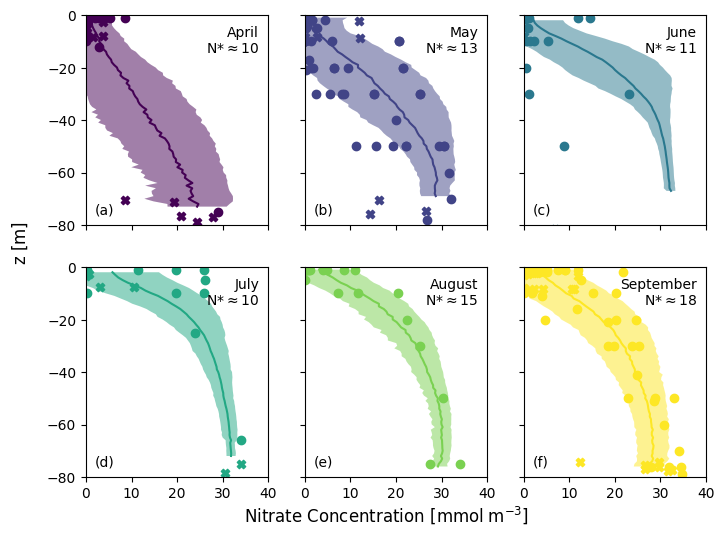

In [30]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(8, 6))

for i, m in enumerate(range(4, 10)):
    monthly_data = midshelf_nitrate_monthly.sel(month=m)
    monthly_ooi_crse_data = mid_shelf_ooi_crse["nitrate"].sel(time=mid_shelf_ooi_crse["time.month"] == m).stack(z=[...])  # noqa: PD013
    ax = cast(plt.Axes, axs.flatten()[i])
    ax.plot(
        monthly_data["mean"],
        -monthly_data["depth"],
        color=colors[i],
    )
    ax.scatter(
        mid_nhl_crse.sel(time=mid_nhl_crse["time.month"] == m)["nitrate"],
        -mid_nhl_crse.sel(time=mid_nhl_crse["time.month"] == m)["pressure"],
        color=colors[i],
    )
    ax.scatter(
        monthly_ooi_crse_data,
        -monthly_ooi_crse_data["pressure"],
        color=colors[i],
        marker="X",  # pyright: ignore[reportArgumentType]
    )
    ax.fill_betweenx(
        -monthly_data["depth"],
        monthly_data["mean"] - monthly_data["ci"],  # pyright: ignore[reportArgumentType]
        monthly_data["mean"] + monthly_data["ci"],  # pyright: ignore[reportArgumentType]
        ls="None",
        edgecolor="None",
        facecolor=colors[i],
        alpha=0.5,
    )
    ax.annotate(
        f"{calendar.month_name[m]}\nN*$\\approx${np.ceil(monthly_data['count'].mean().to_numpy() / 7):.0f}",
        xy=(0.95, 0.95),
        xycoords="axes fraction",
        fontsize=10,
        ha="right",
        verticalalignment="top",
    )
    ax.annotate(
        f"({string.ascii_lowercase[i]})",
        xy=(0.05, 0.05),
        xycoords="axes fraction",
        fontsize=10,
        ha="left",
    )
    ax.set_xlim(0, 40)
    ax.set_ylim(-80, 0)
    ax.minorticks_off()

fig.supxlabel("Nitrate Concentration [$\\mathsf{m mol \\; m^{-3}}$]", y=0.03)
fig.supylabel("z [$\\mathsf{{m}}$]", x=0.03)

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/midshelf-mean-profiles-with-bottle-samples.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    bbox_inches="tight",
    dpi=1200,
)